# PSTHEstimation\n\nPSTH estimation from a simulated point process.\n\nPython port of the MATLAB `PSTHEstimation` helpfile (`helpfiles/PSTHEstimation.m`).

In [1]:
from pathlib import Path
import sys
REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from nstat import Covariate, nspikeTrain, nstColl, CIF
from nstat.notebook_figures import FigureTracker
np.random.seed(0)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic="PSTHEstimation", output_root=OUTPUT_ROOT, expected_count=2)
def capture(label, fn):
    fig = __tracker.new_figure(label); plt.close(fig); fn(); __tracker._active_fig = plt.gcf()


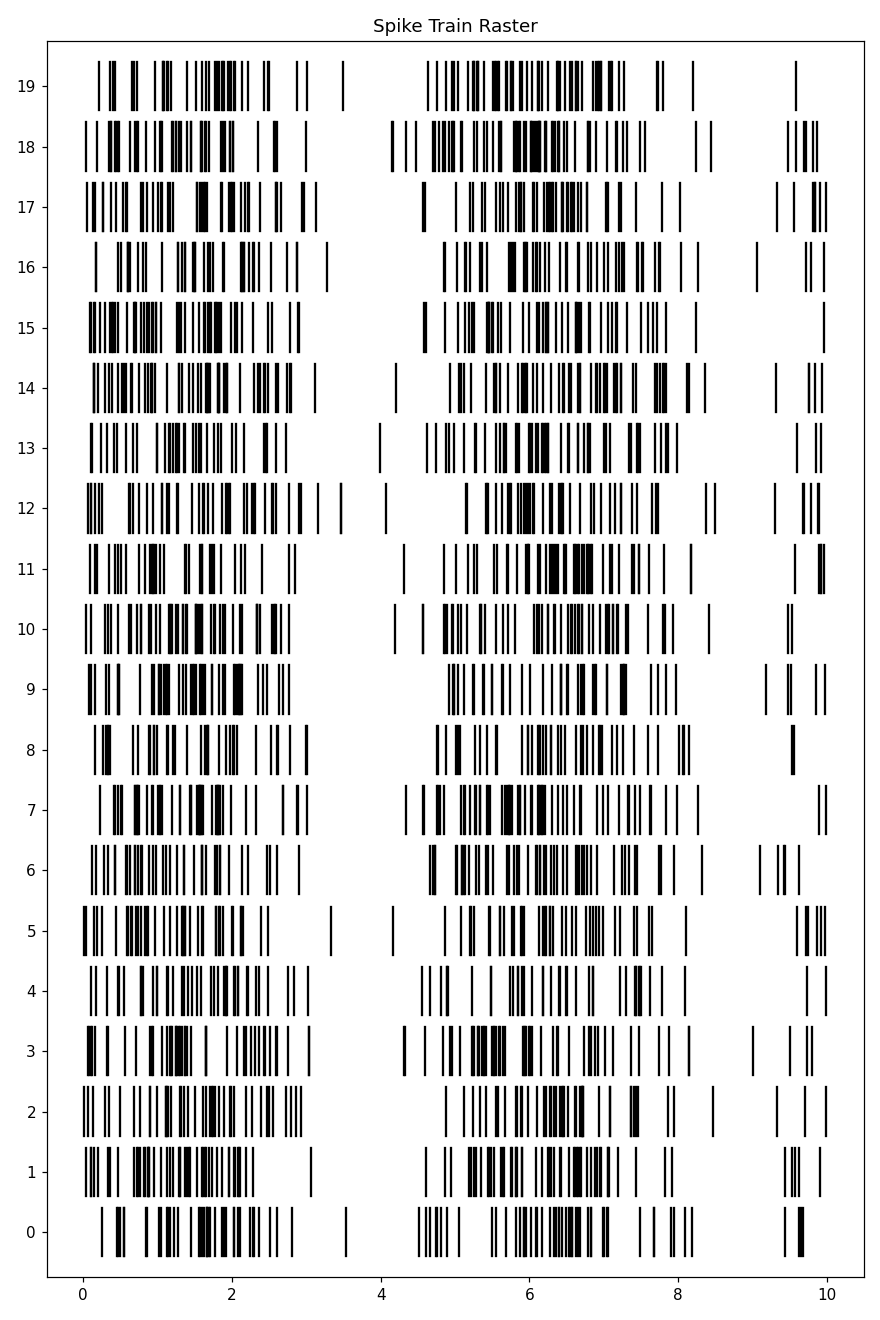

{'psth_mean_hz': 9.639999999999999, 'psth_glm_mean_hz': 9.639036631095, 'lambda_mean_hz': 10.0}


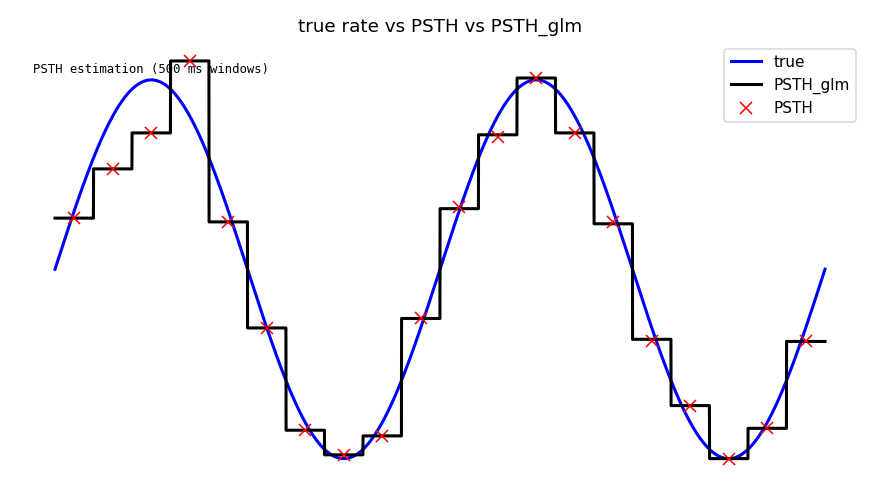

In [2]:
delta = 0.001; Tmax = 10; time = np.arange(0, Tmax + delta, delta); f = 0.2
lambdaData = 10*np.sin(2*np.pi*f*time) + 10
lam = Covariate(time, lambdaData, "Lambda(t)", "time", "s", "Hz", ["lambda_1"])
spikeColl = CIF.simulateCIFByThinningFromLambda(lam, 20, seed=0)

capture("simulated raster (CIF thinning) of known rate", lambda: spikeColl.plot())

__tracker.new_figure("PSTH estimation (500 ms windows)")
binsize = 0.5
psth = spikeColl.psth(binsize); psthGLM = spikeColl.psthGLM(binwidth=binsize)[0]
plt.plot(np.asarray(lam.time).flatten(), np.asarray(lam.dataToMatrix()).flatten(), "b", linewidth=2, label="true")
plt.plot(np.asarray(psthGLM.time).flatten(), np.asarray(psthGLM.dataToMatrix()).flatten(), "k", linewidth=2, label="PSTH_glm")
plt.plot(np.asarray(psth.time).flatten(), np.asarray(psth.dataToMatrix()).flatten(), "rx", markersize=8, label="PSTH")
plt.legend()
plt.title("true rate vs PSTH vs PSTH_glm"); plt.xlabel("time (s)"); plt.ylabel("Hz")
parity = {
    "psth_mean_hz": float(np.mean(np.asarray(psth.dataToMatrix()))),
    "psth_glm_mean_hz": float(np.mean(np.asarray(psthGLM.dataToMatrix()))),
    "lambda_mean_hz": float(np.mean(np.asarray(lam.dataToMatrix()))),
}
print(parity)
__tracker.finalize()
